In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.path as mplPath
from matplotlib import pyplot
import geopandas as gpd
import pandas as pd
import cartopy.io.shapereader as shpreader
import geodatasets
import xarray as xr
import numpy as np
from geopandas import GeoSeries
from pathlib import Path
from pyproj import Transformer
from shapely.geometry import Point , Polygon, MultiPolygon
from shapely.geometry.multipolygon import MultiPolygon
import shapely.wkt
import shapely.geometry
import shapely
from shapely.ops import nearest_points
from pathlib import Path
import rasterio
import rioxarray

In [2]:
### Optimized version - Direct settlement distance and SI calculation ###
from scipy.spatial import cKDTree

# Load and prepare data
thailandmap = gpd.read_file('Data\\tha_admbnda_adm1_rtsd_20220121\\tha_admbnda_adm1_rtsd_20220121.shp')
min_lon, max_lat, max_lon, min_lat = thailandmap.unary_union.bounds

# Load and subset land cover data
xr_landuse = xr.open_dataset("Data//dataset-satellite-land-cover//C3S-LC-L4-LCCS-Map-300m-P1Y-2022-v2.1.1.nc")
xr_landuse = xr_landuse.sel(lat=slice(min_lat, max_lat), lon=slice(min_lon, max_lon))
xr_landuse = xr_landuse.reindex(lat=xr_landuse.lat[::-1])
xr_landuse = xr_landuse.sel(time='2022-01-01').drop_vars('time')
lccs_resolution = 300  # meters

# Extract settlement areas
settlement_mask = (xr_landuse['lccs_class'] == 190)

# Get all coordinates as arrays
lats = xr_landuse['lat'].values
lons = xr_landuse['lon'].values
lon_grid, lat_grid = np.meshgrid(lons, lats)

# Get settlement points in lat/lon
settlement_indices = np.where(settlement_mask.values)
settlement_lons = lon_grid[settlement_indices]
settlement_lats = lat_grid[settlement_indices]

# Vectorized coordinate transformation for all points
transformer = Transformer.from_crs('EPSG:4326', 'EPSG:3857', always_xy=True)
settlement_x, settlement_y = transformer.transform(settlement_lons, settlement_lats)
settlement_points_proj = np.column_stack([settlement_x, settlement_y])

# Transform all grid points
all_x, all_y = transformer.transform(lon_grid.ravel(), lat_grid.ravel())
all_points_proj = np.column_stack([all_x, all_y])

# Build KDTree for efficient spatial queries (memory-optimized)
tree = cKDTree(settlement_points_proj)
distances, _ = tree.query(all_points_proj, k=1, workers=-1)
distance_grid = distances.reshape(lon_grid.shape)

# Create xarray with distances
xr_distance = xr.Dataset(
    {'distance': (['lat', 'lon'], distance_grid)},
    coords={'lat': lats, 'lon': lons}
)

print("Distance calculation complete")
print(f"Grid shape: {distance_grid.shape}")
print(f"Settlement points found: {len(settlement_points_proj)}")
print(f"Min distance: {np.min(distances):.2f}m, Max distance: {np.max(distances):.2f}m")


C:\Users\595078\AppData\Local\Temp\ipykernel_17888\549134655.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  min_lon, max_lat, max_lon, min_lat = thailandmap.unary_union.bounds


Distance calculation complete
Grid shape: (5346, 2985)
Settlement points found: 68554
Min distance: 0.00m, Max distance: 329170.70m


In [3]:
### Optimized SI calculation using vectorized NumPy operations ###

# Load existing landcover SI
xr_landuse_si = xr.open_dataset('Output\\xr_SI_Landcover.nc')

# Get distance array
dist = xr_distance['distance'].values

# Define threshold constants
threshold_1000 = 1000 + lccs_resolution
threshold_1500 = 1500 + lccs_resolution
threshold_2000 = 2000 + lccs_resolution
threshold_3000 = 3000 + lccs_resolution

# Vectorized SI calculations for each energy type
# BGEC: 0 if < 1300m, else 3
si_bgec = np.where(dist < threshold_1000, 0, 3).astype(float)

# Biomass: 0 if < 1300m, else 3
si_biomass = np.where(dist < threshold_1000, 0, 3).astype(float)

# Wind: 0 if < 1300m, 2 if 1300-3300m, 3 if > 3300m
si_wind = np.where(
    dist < threshold_1000, 0,
    np.where(dist < threshold_3000, 2, 3)
).astype(float)

# Solar: 0 if < 1300m, 2 if 1300-1800m, 3 if > 1800m
si_solar = np.where(
    dist < threshold_1000, 0,
    np.where(dist < threshold_1500, 2, 3)
).astype(float)

# BGWW: 0 if < 1300m, else 3
si_bgww = np.where(dist < threshold_1000, 0, 3).astype(float)

# MSW: stepped suitability
si_msw = np.where(
    dist < threshold_1000, 0,
    np.where(
        dist < threshold_1500, 1,
        np.where(dist < threshold_2000, 2, 3)
    )
).astype(float)

# IEW: stepped suitability
si_iew = np.where(
    dist < threshold_1000, 0,
    np.where(
        dist < threshold_1500, 1,
        np.where(dist < threshold_2000, 2, 3)
    )
).astype(float)

# Apply landcover mask (set to 0 where landcover SI is 0)
for si_arr, si_name in [(si_bgec, 'SI_BGEC'), (si_biomass, 'SI_Biomass'), 
                         (si_wind, 'SI_Wind'), (si_solar, 'SI_Solar'),
                         (si_bgww, 'SI_BGWW'), (si_msw, 'SI_MSW'), (si_iew, 'SI_IEW')]:
    si_arr[xr_landuse_si[si_name].values == 0] = 0

# Create xarray dataset with all SI variables
xr_si_distance = xr.Dataset(
    {
        'SI_BGEC': (['lat', 'lon'], si_bgec),
        'SI_Biomass': (['lat', 'lon'], si_biomass),
        'SI_Wind': (['lat', 'lon'], si_wind),
        'SI_Solar': (['lat', 'lon'], si_solar),
        'SI_BGWW': (['lat', 'lon'], si_bgww),
        'SI_MSW': (['lat', 'lon'], si_msw),
        'SI_IEW': (['lat', 'lon'], si_iew),
    },
    coords={'lat': lats, 'lon': lons}
)

print(xr_si_distance)


<xarray.Dataset> Size: 894MB
Dimensions:     (lat: 5346, lon: 2985)
Coordinates:
  * lat         (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon         (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    SI_BGEC     (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_Biomass  (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_Wind     (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_Solar    (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_BGWW     (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_MSW      (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_IEW      (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0


In [4]:
### Save results directly (no unnecessary groupby/aggregation needed) ###
xr_si_distance.to_netcdf(path='Output\\xr_SI_Distancetosettlementarea.nc')
print("Distance to settlement suitability index saved successfully")
print(xr_si_distance)


Distance to settlement suitability index saved successfully
<xarray.Dataset> Size: 894MB
Dimensions:     (lat: 5346, lon: 2985)
Coordinates:
  * lat         (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon         (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    SI_BGEC     (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_Biomass  (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_Wind     (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_Solar    (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_BGWW     (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_MSW      (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_IEW      (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0


Text(0.5, 1.0, 'WindSuitability Index - Distance to Settlement')

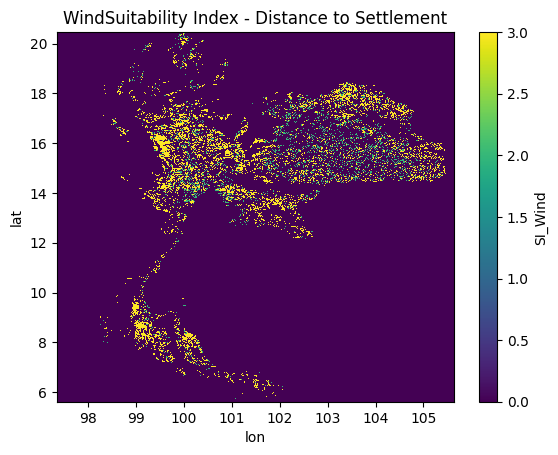

In [5]:
xr_si_distance['SI_Wind'].plot()
plt.title('WindSuitability Index - Distance to Settlement')
